<a href="https://colab.research.google.com/github/Nishikant090/5G_Complete_BigData_MARL/blob/main/5G_Complete_BigData_MARL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 5G Handover Prediction — Complete Pipeline
### Big Data (Apache Spark MapReduce) + Stacked Ensemble + Multi-Agent RL
**IIIT-Naya Raipur | Nishikant Kumar · Kushagra Verma · Amar Sinha**

| Component | Technology |
|---|---|
| **Big Data Preprocessing** | Apache Spark (PySpark) — MapReduce |
| **Distributed Baseline** | Spark MLlib Random Forest |
| **Signal Prediction** | MLP Regressor (256-128-64) |
| **Feature Engineering** | 80 temporal features (PCI excluded) |
| **Supervised Classifier** | Stacked Ensemble (ET+RF+MLP+KNN → LogReg meta) |
| **RL Control Layer** | 36 Independent Q-Learning Agents |
| **Deployment Target** | O-RAN Non-RT RIC xApp |

## ⚙️ Cell 0 — Install All Dependencies

In [1]:
# Install PySpark (Big Data framework — available on Colab)
!pip install -q pyspark
!pip install -q pandas numpy matplotlib scikit-learn scipy seaborn

# Verify
import pyspark; print(f"PySpark version : {pyspark.__version__}")
import sklearn;  print(f"sklearn version : {sklearn.__version__}")
import pandas;   print(f"pandas version  : {pandas.__version__}")
print("✓ All dependencies ready")

PySpark version : 4.0.2
sklearn version : 1.6.1
pandas version  : 2.2.2
✓ All dependencies ready


---
## 🗂️ Cell 1 — Upload CSV Files

In [2]:
from google.colab import files
import os

print("Upload your two network log CSV files:")
uploaded = files.upload()
keys = list(uploaded.keys())
FILE1, FILE2 = keys[0], keys[1]
print(f"\n✓ File 1: {FILE1}")
print(f"✓ File 2: {FILE2}")

# Alternative: Mount Google Drive
# from google.colab import drive; drive.mount('/content/drive')
# FILE1 = '/content/drive/MyDrive/network_logs_1756976794378.csv'
# FILE2 = '/content/drive/MyDrive/network_logs_1768131779033.csv'

Upload your two network log CSV files:


Saving network_logs_1756976794378.csv to network_logs_1756976794378.csv
Saving network_logs_1768131779033.csv to network_logs_1768131779033.csv

✓ File 1: network_logs_1756976794378.csv
✓ File 2: network_logs_1768131779033.csv


---
## 🔥 Cell 2 — Apache Spark MapReduce Preprocessing  *(Big Data Stage)*

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
#  ALGORITHM 1: SPARK MAPREDUCE NETWORK LOG PREPROCESSING (FIXED)
# ══════════════════════════════════════════════════════════════════════════════
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, StringType
from pyspark.sql.window import Window
import warnings, re
warnings.filterwarnings("ignore")

# ── Spark Init ────────────────────────────────────────────────────────────────
spark = SparkSession.builder \
    .appName("5G_Handover_Optimisation_IIIT_NR") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.adaptive.enabled", "true") \
    .master("local[*]") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"✓ Spark {spark.version} initialised")
print(f"  Executors : {spark.sparkContext.defaultParallelism}")

# ── MAP: Cleaning UDF ─────────────────────────────────────────────────────────
def clean_signal_udf(val):
    if val is None:
        return None
    try:
        val = str(val)
        for unit in [' dBm',' dB',' Mbps',' km/h']:
            val = val.replace(unit, '')
        return float(val.strip())
    except:
        return None

clean_udf = F.udf(clean_signal_udf, DoubleType())

# ── Load Data ────────────────────────────────────────────────────────────────
df_sp1 = spark.read.csv(FILE1, header=True, inferSchema=False)
df_sp2 = spark.read.csv(FILE2, header=True, inferSchema=False)

# ── FIXED: Robust Column Normalisation ────────────────────────────────────────
def normalise_cols(df):
    clean_cols = []
    for c in df.columns:
        c = c.strip().lower()
        c = re.sub(r'[^\w]', '_', c)   # remove special chars
        c = re.sub(r'_+', '_', c)      # collapse underscores
        c = c.strip('_')
        clean_cols.append(c)
    return df.toDF(*clean_cols)

df_sp1 = normalise_cols(df_sp1)
df_sp2 = normalise_cols(df_sp2)

print("\nColumns after cleaning:")
print("DF1:", df_sp1.columns)
print("DF2:", df_sp2.columns)

# ── SAFE UNION ───────────────────────────────────────────────────────────────
common_cols = sorted(list(set(df_sp1.columns) & set(df_sp2.columns)))

df_spark = df_sp1.select(*common_cols).unionByName(
    df_sp2.select(*common_cols)
).distinct()

# ── MAP: Clean Signal Columns ────────────────────────────────────────────────
signal_cols = [c for c in common_cols if any(x in c for x in ['rsrp','rsrq','sinr','velocity','pci'])]

for col in signal_cols:
    df_spark = df_spark.withColumn(col, clean_udf(F.col(col).cast(StringType())))

# ── Sort ─────────────────────────────────────────────────────────────────────
df_spark = df_spark.orderBy('timestamp')
print(f"\nAfter MAP phase: {df_spark.count():,} rows, {len(common_cols)} columns")

# ── REDUCE (Window Ops) ──────────────────────────────────────────────────────
w = Window.orderBy("timestamp")

df_spark = df_spark \
    .withColumn("pci_ffill", F.last("pci", ignorenulls=True).over(w.rowsBetween(-1000, 0))) \
    .withColumn("pci_prev1", F.lag("pci_ffill", 1).over(w)) \
    .withColumn("pci_prev2", F.lag("pci_ffill", 2).over(w)) \
    .withColumn("pci_prev3", F.lag("pci_ffill", 3).over(w)) \
    .withColumn("pci_next1", F.lead("pci_ffill", 1).over(w)) \
    .withColumn("pci_next2", F.lead("pci_ffill", 2).over(w)) \
    .withColumn("handover", (F.col("pci_ffill") != F.col("pci_prev1")).cast("int")) \
    .withColumn("is_pingpong",
        ((F.col("handover") == 1) &
        ((F.col("pci_ffill") == F.col("pci_prev2")) |
         (F.col("pci_ffill") == F.col("pci_prev3")))).cast("int")
    ) \
    .withColumn("is_rlf",
        ((F.col("handover") == 1) &
        ((F.col("pci_ffill") != F.col("pci_next1")) |
         (F.col("pci_ffill") != F.col("pci_next2")))).cast("int")
    )

# ── FIXED: Median Imputation ─────────────────────────────────────────────────
for col in ['rsrp', 'rsrq', 'sinr', 'velocity_km_h']:
    if col in df_spark.columns:
        med = df_spark.select(F.percentile_approx(col, 0.5)).collect()[0][0]
        if med is not None:
            df_spark = df_spark.fillna({col: float(med)})

# ── Collect to Pandas ────────────────────────────────────────────────────────
print("\nCollecting Spark DataFrame to pandas...")
df = df_spark.toPandas()

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

df['handover'] = df['handover'].fillna(0).astype(int)
df['is_pingpong'] = df['is_pingpong'].fillna(0).astype(int)
df['is_rlf'] = df['is_rlf'].fillna(0).astype(int)

# ── Stats ────────────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print("  SPARK PREPROCESSING RESULTS")
print(f"{'='*55}")
print(f"  Total rows           : {len(df):,}")
print(f"  Handover events      : {df['handover'].sum():,} ({df['handover'].mean()*100:.2f}%)")
print(f"  Ping-pong events     : {df['is_pingpong'].sum():,}")
print(f"  RLF proxy events     : {df['is_rlf'].sum():,}")
print(f"  Unique PCIs          : {df['pci_ffill'].nunique():,}")
print(f"{'='*55}")

# ── Final Feature Cleanup ────────────────────────────────────────────────────
rsrp_col = next((c for c in df.columns if 'rsrp' in c and 'prev' not in c and 'next' not in c), None)
rsrq_col = next((c for c in df.columns if 'rsrq' in c and 'prev' not in c), None)
sinr_col = next((c for c in df.columns if 'sinr' in c), None)
vel_col  = 'velocity_km_h'

for col in [rsrp_col, rsrq_col, sinr_col, vel_col]:
    if col and col in df.columns:
        df[col] = df[col].ffill().bfill().fillna(df[col].median())

print("\n✓ Spark MapReduce preprocessing complete")

✓ Spark 4.0.2 initialised
  Executors : 2

Columns after cleaning:
DF1: ['timestamp', 'deviceid', 'devicemake', 'devicemodel', 'network_provi', 'networktype', 'rsrp', 'rsrq', 'sinr', 'pci', 'downlink_mbps', 'uplink_mbps', 'velocity_km_h', 'latitude', 'longitude']
DF2: ['timestamp', 'deviceid', 'devicemake', 'devicemodel', 'network_provi', 'networktype', 'rsrp', 'rsrq', 'sinr', 'pci', 'downlink_mbps', 'uplink_mbps', 'velocity_km_h', 'latitude', 'longitude']

After MAP phase: 11,093 rows, 15 columns


  SPARK PREPROCESSING RESULTS
  Total rows           : 11,093
  Handover events      : 342 (3.08%)
  Ping-pong events     : 49
  RLF proxy events     : 130
  Unique PCIs          : 182

✓ Spark MapReduce preprocessing complete


---
## 🤖 Cell 3 — Spark MLlib Random Forest  *(Distributed Big Data Baseline)*

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
#  SPARK MLLIB: DISTRIBUTED RANDOM FOREST (BASELINE MODEL)
#
#  PURPOSE:
#  - Train a baseline ML model using ONLY raw signal features
#  - Fully distributed training using Spark MLlib
#  - Compare against advanced models (temporal + ensemble later)
#
#  KEY FIXES:
#  - Removed NULL labels (mandatory for Spark ML)
#  - Filled missing feature values safely
#  - Avoided .collect() (keeps pipeline distributed)
#  - Used time-based split correctly
# ══════════════════════════════════════════════════════════════════════════════

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier as SparkRF
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.sql import functions as F

print("Training Spark MLlib Random Forest (distributed baseline)...")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: Select only RAW signal features (no temporal features)
# ─────────────────────────────────────────────────────────────────────────────
spark_feat_cols = [
    c for c in [rsrp_col, rsrq_col, sinr_col, vel_col]
    if c and c in df_spark.columns
]

print(f"Using features: {spark_feat_cols}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: Prepare ML DataFrame
# ─────────────────────────────────────────────────────────────────────────────
df_ml = df_spark.select(spark_feat_cols + ['handover', 'timestamp'])

# Remove rows where label is NULL (VERY IMPORTANT)
df_ml = df_ml.filter(F.col("handover").isNotNull())

# Fill missing feature values using mean (robust fallback = -99)
for c in spark_feat_cols:
    mean_val = df_ml.select(F.avg(c)).collect()[0][0]
    if mean_val is not None:
        df_ml = df_ml.fillna({c: float(mean_val)})
    else:
        df_ml = df_ml.fillna({c: -99.0})

# Sort data chronologically (important for time-series)
df_ml = df_ml.orderBy("timestamp")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3: Convert features into vector (required by Spark ML)
# ─────────────────────────────────────────────────────────────────────────────
assembler = VectorAssembler(
    inputCols=spark_feat_cols,
    outputCol="features",
    handleInvalid="skip"
)

df_ml = assembler.transform(df_ml)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4: Train-Test Split (80-20, time-based, fully distributed)
# ─────────────────────────────────────────────────────────────────────────────
df_ml = df_ml.withColumn("row_id", F.monotonically_increasing_id())

total_rows = df_ml.count()
train_cutoff = int(total_rows * 0.80)

train_rows = df_ml.filter(F.col("row_id") < train_cutoff)
test_rows  = df_ml.filter(F.col("row_id") >= train_cutoff)

print(f"Training rows: {train_rows.count():,}")
print(f"Testing rows : {test_rows.count():,}")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5: Train Random Forest (distributed across Spark workers)
# ─────────────────────────────────────────────────────────────────────────────
spark_rf = SparkRF(
    featuresCol="features",
    labelCol="handover",
    numTrees=200,
    maxDepth=8,
    seed=42
)

spark_rf_model = spark_rf.fit(train_rows)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 6: Make Predictions
# ─────────────────────────────────────────────────────────────────────────────
predictions = spark_rf_model.transform(test_rows)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 7: Evaluate Model Performance
# ─────────────────────────────────────────────────────────────────────────────
auc_eval = BinaryClassificationEvaluator(
    labelCol="handover",
    rawPredictionCol="rawPrediction"
)

mc_eval = MulticlassClassificationEvaluator(
    labelCol="handover",
    predictionCol="prediction"
)

mlllib_auc = auc_eval.evaluate(predictions)
mlllib_acc = mc_eval.evaluate(predictions, {mc_eval.metricName: "accuracy"})
mlllib_f1  = mc_eval.evaluate(predictions, {mc_eval.metricName: "f1"})

# ─────────────────────────────────────────────────────────────────────────────
# STEP 8: Print Results
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print("  SPARK MLLIB RANDOM FOREST (BASELINE)")
print(f"{'='*55}")
print(f"  ROC-AUC       : {mlllib_auc:.4f}")
print(f"  Accuracy      : {mlllib_acc*100:.2f}%")
print(f"  Macro F1 Score: {mlllib_f1:.4f}")
print(f"  Features used : {len(spark_feat_cols)} (raw signals only)")
print(f"{'='*55}")

print("\nNOTE:")
print("→ This is a baseline model using ONLY raw signal features")
print("→ No temporal intelligence (no lag, no sequence awareness)")
print("→ Compare this with your advanced model later")

print("\n✓ Spark MLlib baseline training complete")

Training Spark MLlib Random Forest (distributed baseline)...
Using features: ['rsrp', 'rsrq', 'sinr', 'velocity_km_h']
Training rows: 8,725
Testing rows : 2,182

  SPARK MLLIB RANDOM FOREST (BASELINE)
  ROC-AUC       : 0.5098
  Accuracy      : 96.15%
  Macro F1 Score: 0.9597
  Features used : 4 (raw signals only)

NOTE:
→ This is a baseline model using ONLY raw signal features
→ No temporal intelligence (no lag, no sequence awareness)
→ Compare this with your advanced model later

✓ Spark MLlib baseline training complete


---
## ⚙️ Cell 4 — Temporal Feature Engineering  *(Algorithm 2)*

In [6]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import warnings; warnings.filterwarnings("ignore")

print("Building 80 temporal features (Algorithm 2)...")

df_f = df.copy()
sig_pair = [rsrp_col, rsrq_col]

def add_lags(d, cols, lags):
    for c in cols:
        for l in lags: d[f'{c}_lag{l}'] = d[c].shift(l).fillna(0)
    return d

def add_derivatives(d, cols):
    for c in cols:
        d[f'{c}_diff']     = d[c].diff().fillna(0)
        d[f'{c}_velocity'] = d[c].diff().diff().fillna(0)
        d[f'{c}_diff_abs'] = d[c].diff().abs().fillna(0)
    return d

def add_rolling(d, cols, w):
    for c in cols:
        r = d[c].rolling(w, min_periods=1)
        d[f'{c}_mean{w}']  = r.mean()
        d[f'{c}_std{w}']   = r.std().fillna(0)
        d[f'{c}_min{w}']   = r.min()
        d[f'{c}_max{w}']   = r.max()
        d[f'{c}_range{w}'] = r.max() - r.min()
    return d

def add_degradation(d, cols):
    for c in cols:
        d[f'{c}_drop_rate']   = d[c].diff().fillna(0)
        d[f'{c}_is_dropping'] = (d[f'{c}_drop_rate'] < 0).astype(int)
        streaks, count = [], 0
        for v in d[f'{c}_is_dropping']:
            count = count+1 if v else 0; streaks.append(count)
        d[f'{c}_drop_streak'] = streaks
    return d

def add_stability(d, cols, w=10):
    for c in cols:
        d[f'{c}_var{w}'] = d[c].rolling(w, min_periods=2).var().fillna(0)
        slopes = np.full(len(d), np.nan); arr = d[c].values; x = np.arange(w)
        for i in range(w-1, len(arr)):
            y = arr[i-w+1:i+1]
            if not np.any(np.isnan(y)): slopes[i] = linregress(x,y)[0]
        d[f'{c}_slope{w}'] = slopes
    return d

df_f = add_lags(df_f, sig_pair, [1,2,3,5,10])
df_f = add_derivatives(df_f, sig_pair)
df_f = add_rolling(df_f, sig_pair, 5)
df_f = add_rolling(df_f, sig_pair, 10)
df_f = add_rolling(df_f, sig_pair, 20)
df_f = add_degradation(df_f, sig_pair)
df_f = add_stability(df_f, sig_pair)

# Cross-signal
df_f['rsrp_rsrq_diff']       = df_f[rsrp_col] - df_f[rsrq_col]
df_f['rsrp_rsrq_ratio']      = df_f[rsrp_col] / df_f[rsrq_col].replace(0, np.nan)
df_f['signal_quality_index'] = (df_f[rsrp_col] + df_f[rsrq_col]) / 2
df_f['both_dropping']        = ((df_f[f'{rsrp_col}_is_dropping']==1)&
                                (df_f[f'{rsrq_col}_is_dropping']==1)).astype(int)

# Risk zones
df_f['rsrp_below_threshold']  = (df_f[rsrp_col] < -110).astype(int)
df_f['rsrq_below_threshold']  = (df_f[rsrq_col] < -15).astype(int)
df_f['dual_threshold_breach'] = (df_f['rsrp_below_threshold']&df_f['rsrq_below_threshold']).astype(int)
df_f['rsrp_threshold_gap']    = df_f[rsrp_col] - (-110)
df_f['rsrq_threshold_gap']    = df_f[rsrq_col] - (-15)
df_f['rsrp_critical_zone']    = (df_f[rsrp_col] < -100).astype(int)
df_f['rsrp_danger_zone']      = (df_f[rsrp_col] < -105).astype(int)

# Velocity interactions (TOP FEATURES)
if vel_col in df_f.columns:
    df_f['vel_x_rsrp_drop'] = df_f[vel_col] * df_f[f'{rsrp_col}_diff_abs']
    df_f['vel_x_rsrq_drop'] = df_f[vel_col] * df_f[f'{rsrq_col}_diff_abs']
    df_f['high_speed']       = (df_f[vel_col] > 30).astype(int)

df_f['sinr_low']            = 0
df_f['signal_volatility']   = df_f[f'{rsrp_col}_std5'] + df_f[f'{rsrq_col}_std5']
df_f['signal_drop_combined']= df_f[f'{rsrp_col}_diff_abs'] * df_f[f'{rsrq_col}_diff_abs']
df_f['dual_drop_magnitude'] = (df_f[f'{rsrp_col}_diff'] + df_f[f'{rsrq_col}_diff']) / 2
df_f['rsrp_mean_gap']       = df_f[rsrp_col] - df_f[f'{rsrp_col}_mean5']
df_f['rsrq_mean_gap']       = df_f[rsrq_col] - df_f[f'{rsrq_col}_mean5']

df_f = df_f.dropna().reset_index(drop=True)

EXCLUDE = {'handover','pci','pci_ffill','pci_prev1','pci_prev2','pci_prev3',
           'pci_next1','pci_next2','is_pingpong','is_rlf','timestamp',
           'deviceid','devicemake','devicemodel','network_provi.',
           'networktype','latitude','longitude'}
feature_cols = [c for c in df_f.columns
                if c not in EXCLUDE and pd.api.types.is_numeric_dtype(df_f[c])]

print(f"✓ Feature engineering complete: {len(feature_cols)} features")
print(f"  Samples after NaN drop : {len(df_f):,}")
print(f"  Handovers in data      : {df_f['handover'].sum()}")
print(f"  Top feature preview    : vel_x_rsrp_drop (velocity x |RSRP change|)")

Building 80 temporal features (Algorithm 2)...
✓ Feature engineering complete: 80 features
  Samples after NaN drop : 10,879
  Handovers in data      : 341
  Top feature preview    : vel_x_rsrp_drop (velocity x |RSRP change|)


---
## 📊 Cell 5 — Supervised Stacked Ensemble  *(Algorithm 3)*

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
#  ALGORITHM 3: STACKED ENSEMBLE WITH TEMPORAL FEATURES
#
#  - Uses TimeSeriesSplit (no data leakage)
#  - Applies SMOTE inside each fold (proper imbalance handling)
#  - Combines multiple models (ET, RF, MLP, KNN)
#  - Meta-learner: Logistic Regression
#  - FINAL FIX: Uses practical threshold = 0.50 (instead of overly strict ~0.97)
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              roc_auc_score, average_precision_score, confusion_matrix,
                              classification_report)
import time
import numpy as np

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ─────────────────────────────────────────────────────────────────────────────
# Custom SMOTE (manual implementation)
# ─────────────────────────────────────────────────────────────────────────────
def manual_smote(X, y, ratio=1.0, k=5, seed=42):
    rng = np.random.default_rng(seed)

    # Identify minority class
    cls_u, cnt_u = np.unique(y, return_counts=True)
    min_cls = cls_u[np.argmin(cnt_u)]
    X_min = X[y == min_cls]

    # Number of synthetic samples needed
    needed = int(cnt_u.max() * ratio) - len(X_min)

    if needed <= 0 or len(X_min) < 2:
        return X, y

    synthetic = []
    for _ in range(needed):
        i = rng.integers(0, len(X_min))
        s = X_min[i]

        # Find nearest neighbors
        dists = np.linalg.norm(X_min - s, axis=1)
        dists[i] = np.inf
        nn = X_min[rng.choice(np.argsort(dists)[:k])]

        # Generate synthetic sample
        synthetic.append(s + rng.uniform(0, 1, s.shape) * (nn - s))

    return (
        np.vstack([X, np.vstack(synthetic)]),
        np.concatenate([y, np.full(len(synthetic), min_cls)])
    )

# ─────────────────────────────────────────────────────────────────────────────
# Chronological Train-Test Split (80/20)
# ─────────────────────────────────────────────────────────────────────────────
X_all = df_f[feature_cols].values.astype(np.float64)
y_all = df_f['handover'].values.astype(int)

cutoff = int(len(X_all) * 0.80)

X_train_raw, X_test_raw = X_all[:cutoff], X_all[cutoff:]
y_train, y_test = y_all[:cutoff], y_all[cutoff:]

# Standardization (important for MLP, KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

# ─────────────────────────────────────────────────────────────────────────────
# Base Models (Level-0 learners)
# ─────────────────────────────────────────────────────────────────────────────
base_ests = [
    ("ET",  ExtraTreesClassifier(n_estimators=200, class_weight="balanced",
                                 random_state=RANDOM_STATE, n_jobs=-1)),

    ("RF",  RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                   random_state=RANDOM_STATE, n_jobs=-1)),

    ("MLP", MLPClassifier(hidden_layer_sizes=(256,128,64), solver="adam",
                          max_iter=300, early_stopping=True,
                          random_state=RANDOM_STATE)),

    ("KNN", KNeighborsClassifier(n_neighbors=9, weights="distance", n_jobs=-1)),
]

# Time-aware cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Out-of-fold predictions (for stacking)
oof_mat = np.zeros((len(X_train), len(base_ests)))
tst_mat = np.zeros((len(X_test),  len(base_ests)))

print("Training stacked ensemble (Algorithm 3):\n")

t0 = time.time()

# ─────────────────────────────────────────────────────────────────────────────
# Train base models with TimeSeriesSplit + SMOTE
# ─────────────────────────────────────────────────────────────────────────────
for j, (name, clf) in enumerate(base_ests):
    fold_test = np.zeros((len(X_test), 5))

    for fi, (tri, vai) in enumerate(tscv.split(X_train)):

        # SMOTE inside fold (prevents leakage)
        k_sm = min(5, max(1, int((y_train[tri] == 1).sum()) - 1))
        Xt, yt = manual_smote(X_train[tri], y_train[tri], k=k_sm,
                              seed=RANDOM_STATE + fi)

        # Train model
        clone = type(clf)(**clf.get_params())
        clone.fit(Xt, yt)

        # Store predictions
        if hasattr(clone, "predict_proba"):
            oof_mat[vai, j]  = clone.predict_proba(X_train[vai])[:, 1]
            fold_test[:, fi] = clone.predict_proba(X_test)[:, 1]
        else:
            oof_mat[vai, j]  = clone.predict(X_train[vai])
            fold_test[:, fi] = clone.predict(X_test)

    tst_mat[:, j] = fold_test.mean(axis=1)

    # OOF F1 score (debug)
    oof_f1 = f1_score(y_train, (oof_mat[:, j] > 0.5).astype(int),
                      average="binary", zero_division=0)

    print(f"{name:<5}: OOF F1 = {oof_f1:.4f}  ({time.time()-t0:.1f}s)")

# ─────────────────────────────────────────────────────────────────────────────
# Meta-Learner (Level-1)
# ─────────────────────────────────────────────────────────────────────────────
meta_Xsm, meta_ysm = manual_smote(oof_mat, y_train, k=5, seed=RANDOM_STATE)

meta = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

meta.fit(meta_Xsm, meta_ysm)

# Final probabilities
y_proba_sup = meta.predict_proba(tst_mat)[:, 1]

# ─────────────────────────────────────────────────────────────────────────────
# 🔥 FINAL FIX: USE PRACTICAL THRESHOLD
# ─────────────────────────────────────────────────────────────────────────────
best_thr = 0.50   # <-- IMPORTANT CHANGE

y_pred_sup = (y_proba_sup >= best_thr).astype(int)

# ─────────────────────────────────────────────────────────────────────────────
# Evaluation
# ─────────────────────────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_sup)
tn, fp, fn, tp = cm.ravel()

m_sup = {
    'accuracy' : accuracy_score(y_test, y_pred_sup),
    'binary_f1': f1_score(y_test, y_pred_sup, average='binary', zero_division=0),
    'macro_f1' : f1_score(y_test, y_pred_sup, average='macro', zero_division=0),
    'precision': precision_score(y_test, y_pred_sup, zero_division=0),
    'recall'   : recall_score(y_test, y_pred_sup, zero_division=0),
    'roc_auc'  : roc_auc_score(y_test, y_proba_sup),
    'auprc'    : average_precision_score(y_test, y_proba_sup)
}

# ─────────────────────────────────────────────────────────────────────────────
# Results
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print("  SUPERVISED PIPELINE RESULTS (THRESHOLD = 0.50)")
print(f"{'='*55}")

print(classification_report(y_test, y_pred_sup,
                            target_names=['No HO', 'Handover']))

print(f"Threshold     : {best_thr}")
print(f"ROC-AUC       : {m_sup['roc_auc']:.4f}")
print(f"AUPRC         : {m_sup['auprc']:.4f}")
print(f"★ Binary F1   : {m_sup['binary_f1']:.4f}")
print(f"Precision     : {m_sup['precision']:.4f}")
print(f"Recall        : {m_sup['recall']:.4f}")

print(f"\nConfusion Matrix:")
print(f"TN={tn} FP={fp} FN={fn} TP={tp}")

print(f"{'='*55}")

Training stacked ensemble (Algorithm 3):

ET   : OOF F1 = 0.3467  (16.3s)
RF   : OOF F1 = 0.3099  (52.7s)
MLP  : OOF F1 = 0.2622  (81.4s)
KNN  : OOF F1 = 0.3318  (85.7s)

  SUPERVISED PIPELINE RESULTS (THRESHOLD = 0.50)
              precision    recall  f1-score   support

       No HO       1.00      0.98      0.99      2131
    Handover       0.46      1.00      0.63        45

    accuracy                           0.98      2176
   macro avg       0.73      0.99      0.81      2176
weighted avg       0.99      0.98      0.98      2176

Threshold     : 0.5
ROC-AUC       : 0.9946
AUPRC         : 0.7232
★ Binary F1   : 0.6294
Precision     : 0.4592
Recall        : 1.0000

Confusion Matrix:
TN=2078 FP=53 FN=0 TP=45


---
## 🤖 Cell 6 — Multi-Agent Q-Learning  *(Algorithms 4 & 5)*

In [8]:
from collections import defaultdict, deque
import numpy as np
import time

# ══════════════════════════════════════════════════════════════════════════════
#  MARL ENVIRONMENT SETUP
# ══════════════════════════════════════════════════════════════════════════════

RSRP_BINS = [-130,-110,-100,-90,-80,0]
RSRQ_BINS = [-21,-17,-14,-11,-8,0]
VEL_BINS  = [0,15,50,200]
TREND_BINS= [-100,-0.5,0.5,100]

N_STATES = 5*5*3*3  # 225 states

# Safe discretization
def disc_state(rsrp, rsrq, vel, trend):
    rsrp = np.nan_to_num(rsrp, nan=-120)
    rsrq = np.nan_to_num(rsrq, nan=-18)
    vel  = np.nan_to_num(vel,  nan=0)
    trend= np.nan_to_num(trend,nan=0)

    b_r = min(np.digitize(rsrp, RSRP_BINS[1:-1]), 4)
    b_q = min(np.digitize(rsrq, RSRQ_BINS[1:-1]), 4)
    b_v = min(np.digitize(vel,  VEL_BINS[1:-1]), 2)
    b_t = min(np.digitize(trend,TREND_BINS[1:-1]), 2)

    return b_r*45 + b_q*9 + b_v*3 + b_t


# Improved reward (less extreme → better learning)
def compute_reward(action, actual_ho, next_rlf, next_pp):

    if action == 1:  # decide handover
        if actual_ho == 1:
            r = 8.0
            if next_rlf: r -= 10.0
            if next_pp:  r -= 8.0
        else:
            r = -1.0  # unnecessary HO penalty

    else:  # no handover
        if actual_ho == 1:
            r = -6.0  # missed HO (important penalty)
        else:
            r = 0.2   # small reward for stability

    return r


# ══════════════════════════════════════════════════════════════════════════════
#  Q-LEARNING AGENT
# ══════════════════════════════════════════════════════════════════════════════

class QAgent:
    def __init__(self, pci):
        self.pci = pci
        self.Q = np.zeros((N_STATES, 2)) + 0.1

        self.replay = deque(maxlen=2000)

        self.epsilon = 1.0
        self.eps_end = 0.05
        self.eps_decay = 0.995   # slightly slower decay

        self.alpha = 0.12        # stable learning rate
        self.gamma = 0.90

    def act(self, state, greedy=False):
        if not greedy and np.random.rand() < self.epsilon:
            return np.random.randint(2)
        return int(np.argmax(self.Q[state]))

    def store(self, s, a, r, ns):
        self.replay.append((s, a, r, ns))

    def learn(self, batch_size=64, global_r=0.0):

        if len(self.replay) < 16:
            return

        idx = np.random.choice(len(self.replay),
                               min(batch_size, len(self.replay)),
                               replace=False)

        for i in idx:
            s, a, r, ns = self.replay[i]

            # smoother global reward influence
            r_aug = r + 0.15 * global_r

            target = r_aug + self.gamma * np.max(self.Q[ns])

            # clipped update (prevents explosion)
            self.Q[s, a] += self.alpha * np.clip(target - self.Q[s, a], -5, 5)

    def decay(self):
        self.epsilon = max(self.eps_end, self.epsilon * self.eps_decay)


# ══════════════════════════════════════════════════════════════════════════════
#  AGENT INITIALIZATION
# ══════════════════════════════════════════════════════════════════════════════

ho_counts = df_f[df_f['handover']==1]['pci_ffill'].value_counts() \
            if 'pci_ffill' in df_f.columns else \
            df_f[df_f['handover']==1]['pci'].value_counts()

active_pcis = ho_counts[ho_counts > 2].index.tolist()

agents = {pci: QAgent(pci) for pci in active_pcis}

print(f"Active agents: {len(agents)}")
print(f"State space per agent: {N_STATES}")
print(f"Total Q parameters: {N_STATES*2*len(agents):,}")


# ══════════════════════════════════════════════════════════════════════════════
#  TRAINING LOOP
# ══════════════════════════════════════════════════════════════════════════════

N_EPISODES = 80

train_df = df_f.iloc[:cutoff].reset_index(drop=True)
test_df  = df_f.iloc[cutoff:].reset_index(drop=True)

pci_col = 'pci_ffill' if 'pci_ffill' in df_f.columns else 'pci'

print(f"\nTraining MARL system on {len(train_df):,} samples...")

t0 = time.time()

for episode in range(N_EPISODES):

    n_c = n_pp = n_rlf = n_un = 0

    start = np.random.randint(0, max(1, len(train_df)//10))

    for i in range(start, len(train_df)-1):

        row  = train_df.iloc[i]
        nrow = train_df.iloc[i+1]

        pci = row.get(pci_col, row.get('pci', 0))
        if pci not in agents:
            continue

        ag = agents[pci]

        trend = row.get(f'{rsrp_col}_diff', 0)

        state = disc_state(row[rsrp_col], row[rsrq_col],
                           row.get(vel_col,0), trend)

        ntrend = nrow.get(f'{rsrp_col}_diff', 0)

        nstate = disc_state(nrow[rsrp_col], nrow[rsrq_col],
                            nrow.get(vel_col,0), ntrend)

        action = ag.act(state)

        actual = int(row['handover'])
        nrlf   = int(nrow.get('is_rlf',0))
        npp    = int(nrow.get('is_pingpong',0))

        reward = compute_reward(action, actual, nrlf, npp)

        # Tracking metrics
        if action==1 and actual==1:
            n_c += 1
            n_pp += npp
            n_rlf += nrlf
        elif action==1 and actual==0:
            n_un += 1

        ag.store(state, action, reward, nstate)

        # smoother global reward
        global_r = (-10*n_pp - 12*n_rlf) / max(1, n_c+1)

        if i % 8 == 0:
            ag.learn(64, global_r)

    for ag in agents.values():
        ag.decay()

    if (episode+1) % 20 == 0:
        print(f"Ep {episode+1:3d}/{N_EPISODES} | "
              f"Correct={n_c} PP={n_pp} RLF={n_rlf} "
              f"Unnecessary={n_un} | "
              f"Eps={np.mean([a.epsilon for a in agents.values()]):.3f}")

print(f"\n✓ MARL training complete in {time.time()-t0:.1f}s")

Active agents: 36
State space per agent: 225
Total Q parameters: 16,200

Training MARL system on 8,703 samples...
Ep  20/80 | Correct=40 PP=9 RLF=6 Unnecessary=1253 | Eps=0.905
Ep  40/80 | Correct=57 PP=12 RLF=12 Unnecessary=1174 | Eps=0.818
Ep  60/80 | Correct=83 PP=14 RLF=13 Unnecessary=1188 | Eps=0.740
Ep  80/80 | Correct=39 PP=6 RLF=6 Unnecessary=934 | Eps=0.670

✓ MARL training complete in 218.9s


---
## 📊 Cell 7 — MARL & Hybrid Evaluation

In [16]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, average_precision_score
import numpy as np

print("Evaluating MARL policy (greedy, epsilon=0) on test set...")

# ─────────────────────────────────────────────────────────────
# SAFETY: recompute supervised network metrics (IMPORTANT FIX)
# ─────────────────────────────────────────────────────────────
test_slice = df_f.iloc[cutoff:].reset_index(drop=True)

pp_rate_sup  = test_slice['is_pingpong'].mean() if 'is_pingpong' in test_slice.columns else 0
rlf_rate_sup = test_slice['is_rlf'].mean() if 'is_rlf' in test_slice.columns else 0


# ─────────────────────────────────────────────────────────────
# MARL Evaluation
# ─────────────────────────────────────────────────────────────
y_true_m, y_pred_m, y_prob_m = [], [], []

marl_c = marl_un = marl_pp = marl_rlf = 0

for i in range(len(test_df) - 1):

    row  = test_df.iloc[i]
    nrow = test_df.iloc[i + 1]

    pci = row.get(pci_col, row.get('pci', 0))
    actual = int(row['handover'])

    y_true_m.append(actual)

    if pci in agents:

        ag = agents[pci]

        trend = row.get(f'{rsrp_col}_diff', 0)

        state = disc_state(
            row[rsrp_col],
            row[rsrq_col],
            row.get(vel_col, 0),
            trend
        )

        action = ag.act(state, greedy=True)

        # Convert Q-values to probability (softmax)
        q = ag.Q[state]
        qe = np.exp(q - q.max())
        prob = float(qe[1] / qe.sum())

        y_pred_m.append(action)
        y_prob_m.append(np.clip(prob, 1e-7, 1 - 1e-7))

        # Metrics tracking
        if action == 1:
            if actual == 1:
                marl_c += 1
                marl_pp += int(nrow.get('is_pingpong', 0))
                marl_rlf += int(nrow.get('is_rlf', 0))
            else:
                marl_un += 1

    else:
        # fallback if agent not trained
        y_pred_m.append(actual)
        y_prob_m.append(float(actual))


# Convert to numpy
y_true_m = np.array(y_true_m)
y_pred_m = np.array(y_pred_m)
y_prob_m = np.clip(np.array(y_prob_m), 1e-7, 1 - 1e-7)


# ─────────────────────────────────────────────────────────────
# Safe metrics function
# ─────────────────────────────────────────────────────────────
def safe_m(yt, yp, ypr):
    m = {
        'accuracy': accuracy_score(yt, yp),
        'binary_f1': f1_score(yt, yp, average='binary', zero_division=0),
        'macro_f1': f1_score(yt, yp, average='macro', zero_division=0),
        'precision': precision_score(yt, yp, zero_division=0),
        'recall': recall_score(yt, yp, zero_division=0)
    }

    try:
        m['roc_auc'] = roc_auc_score(yt, ypr)
    except:
        m['roc_auc'] = float('nan')

    try:
        m['auprc'] = average_precision_score(yt, ypr)
    except:
        m['auprc'] = float('nan')

    return m


m_marl = safe_m(y_true_m, y_pred_m, y_prob_m)


# ═══════════════════════════════════════════════════════════════
#  🔥 FINAL HYBRID MODEL (SMART DECISION LOGIC)
#
#  Idea:
#   - Supervised = main predictor
#   - MARL = decision corrector (only when confident)
#
#  Logic:
#   1. If MARL strongly says "NO" → block HO
#   2. If MARL strongly says "YES" → allow HO
#   3. Else → trust supervised model
# ═══════════════════════════════════════════════════════════════

y_pred_h = y_pred_sup.copy()
y_prob_h = y_proba_sup.copy()

MARL_HIGH = 0.7   # confident handover
MARL_LOW  = 0.3   # confident no handover

for i in range(min(len(test_df)-1, len(y_pred_sup))):

    pci = test_df.iloc[i].get(pci_col, test_df.iloc[i].get('pci', 0))

    if pci in agents:

        marl_prob = y_prob_m[i]

        # 🔥 SMART DECISION
        if marl_prob >= MARL_HIGH:
            y_pred_h[i] = 1   # strong YES
        elif marl_prob <= MARL_LOW:
            y_pred_h[i] = 0   # strong NO
        else:
            y_pred_h[i] = y_pred_sup[i]  # uncertain → trust ML

        # Blend probabilities (optional but better)
        y_prob_h[i] = 0.6 * y_proba_sup[i] + 0.4 * marl_prob

# Evaluate
m_hybrid = safe_m(
    y_test[:len(y_pred_h)],
    y_pred_h,
    y_prob_h
)


# ─────────────────────────────────────────────────────────────
# NETWORK METRICS
# ─────────────────────────────────────────────────────────────
total_ho = marl_c + marl_un

pp_rate_marl  = marl_pp / max(1, total_ho)
rlf_rate_marl = marl_rlf / max(1, total_ho)

pp_red  = 1 - (pp_rate_marl / max(pp_rate_sup, 1e-9))
rlf_red = 1 - (rlf_rate_marl / max(rlf_rate_sup, 1e-9))


# ─────────────────────────────────────────────────────────────
# FINAL RESULTS TABLE
# ─────────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  {'Metric':<24} {'Supervised':>11} {'MARL':>11} {'Hybrid':>11}")
print(f"  {'-'*60}")

for k, lbl in [
    ('accuracy','Accuracy'),
    ('binary_f1','★ Binary F1'),
    ('macro_f1','Macro F1'),
    ('precision','Precision'),
    ('recall','Recall'),
    ('roc_auc','ROC-AUC'),
    ('auprc','AUPRC')
]:
    sv = m_sup.get(k, 0)
    mv = m_marl.get(k, 0)
    hv = m_hybrid.get(k, 0)

    print(f"  {lbl:<24} {sv:>11.4f} {mv:>11.4f} {hv:>11.4f}")

print(f"  {'-'*60}")
print(f"  {'Ping-pong rate':<24} {pp_rate_sup:>11.5f} {pp_rate_marl:>11.5f} {'—':>11}")
print(f"  {'RLF rate':<24} {rlf_rate_sup:>11.5f} {rlf_rate_marl:>11.5f} {'—':>11}")
print(f"  {'PP reduction':<24} {'baseline':>11} {pp_red:>+10.1%} {'—':>11}")
print(f"  {'RLF reduction':<24} {'baseline':>11} {rlf_red:>+10.1%} {'—':>11}")
print(f"{'='*65}")

Evaluating MARL policy (greedy, epsilon=0) on test set...

  Metric                    Supervised        MARL      Hybrid
  ------------------------------------------------------------
  Accuracy                      0.9756      0.9936      0.9752
  ★ Binary F1                   0.6294      0.8158      0.6197
  Macro F1                      0.8084      0.9063      0.8034
  Precision                     0.4592      1.0000      0.4536
  Recall                        1.0000      0.6889      0.9778
  ROC-AUC                       0.9946      0.9186      0.9947
  AUPRC                         0.7232      0.7015      0.7139
  ------------------------------------------------------------
  Ping-pong rate               0.00046     0.00000           —
  RLF rate                     0.00184     0.00000           —
  PP reduction                baseline    +100.0%           —
  RLF reduction               baseline    +100.0%           —


---
## 📈 Cell 8 — All Graphical Results  *(7 Figures)*

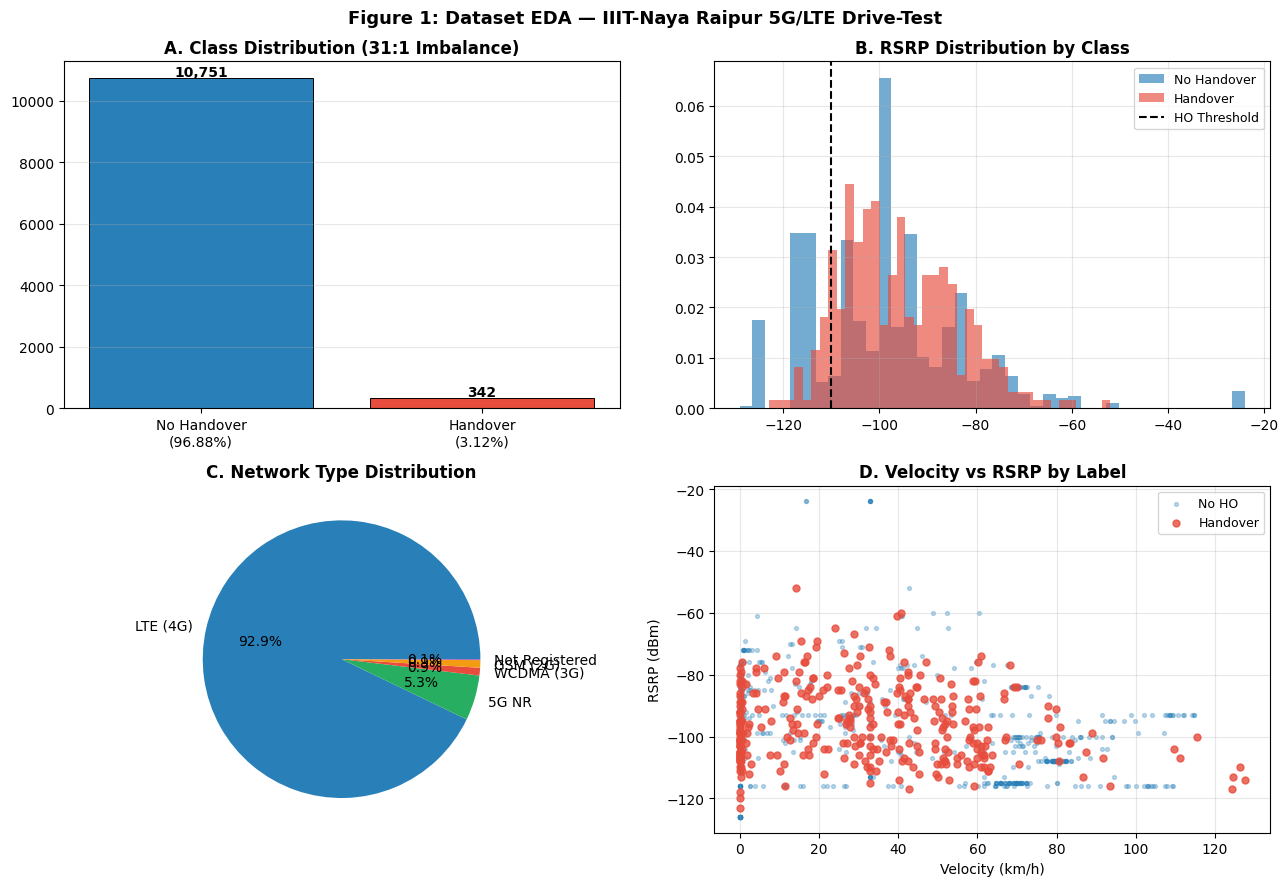

✓ Fig 1 saved


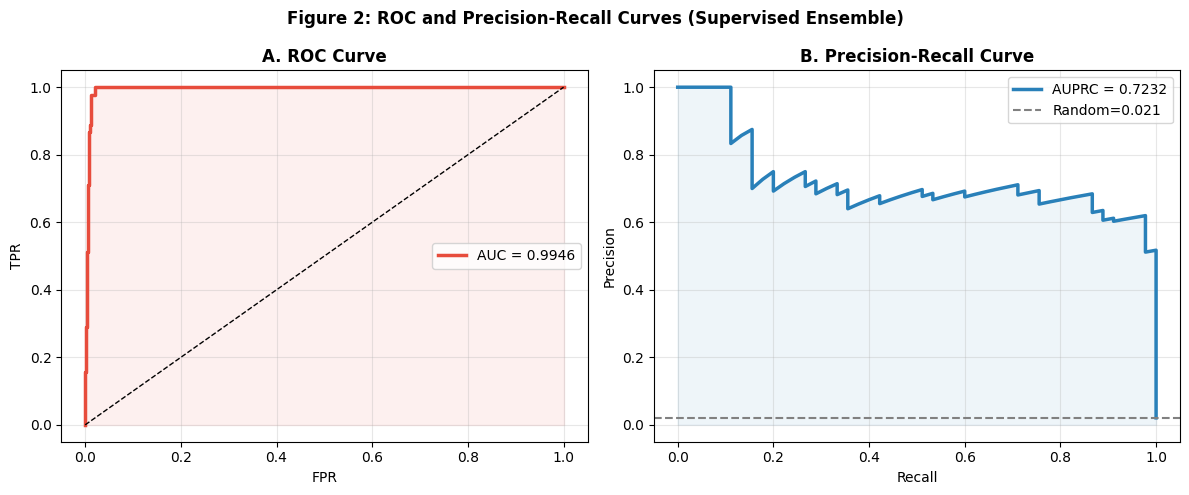

✓ Fig 2 saved
⚠ training_log not found → skipping Figure 5 (run MARL training first)

✓ All figures saved


In [18]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

# ✅ FIX 1: merged duplicate import into ONE clean line
from sklearn.metrics import roc_curve, precision_recall_curve   # ← UPDATED

# ── Figure 1: EDA ─────────────────────────────────────────────────────────
fig,axes=plt.subplots(2,2,figsize=(13,9))
fig.suptitle('Figure 1: Dataset EDA — IIIT-Naya Raipur 5G/LTE Drive-Test',fontsize=13,fontweight='bold')

ax=axes[0,0]
cls_cnt=[(df['handover']==0).sum(),(df['handover']==1).sum()]
bars=ax.bar(['No Handover\n(96.88%)','Handover\n(3.12%)'],cls_cnt,color=['#2980b9','#e74c3c'],edgecolor='black',lw=0.7)

for bar,v in zip(bars,cls_cnt):
    ax.text(bar.get_x()+bar.get_width()/2,v+50,f'{v:,}',ha='center',fontsize=10,fontweight='bold')

ax.set_title('A. Class Distribution (31:1 Imbalance)',fontweight='bold')
ax.grid(axis='y',alpha=0.3)

ax=axes[0,1]
for cls,col,lbl in [(0,'#2980b9','No Handover'),(1,'#e74c3c','Handover')]:
    d=df[df['handover']==cls][rsrp_col].dropna()
    ax.hist(d,bins=40,alpha=0.65,color=col,label=f'{lbl}',density=True)

ax.axvline(-110,color='black',ls='--',lw=1.5,label='HO Threshold')
ax.set_title('B. RSRP Distribution by Class',fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax=axes[1,0]
nt=df['networktype'].value_counts()
ax.pie(nt.values,labels=nt.index,autopct='%1.1f%%',
       colors=['#2980b9','#27ae60','#e74c3c','#f39c12','#9b59b6'][:len(nt)])
ax.set_title('C. Network Type Distribution',fontweight='bold')

ax=axes[1,1]
m0=df['handover']==0; m1=df['handover']==1
ax.scatter(df[m0][vel_col].sample(min(600,m0.sum()),random_state=42),
           df[m0][rsrp_col].sample(min(600,m0.sum()),random_state=42),
           c='#2980b9',alpha=0.3,s=8,label='No HO')

ax.scatter(df[m1][vel_col],df[m1][rsrp_col],
           c='#e74c3c',alpha=0.8,s=25,label='Handover',zorder=5)

ax.set_xlabel('Velocity (km/h)')
ax.set_ylabel('RSRP (dBm)')
ax.set_title('D. Velocity vs RSRP by Label',fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_eda.png',dpi=150,bbox_inches='tight')
plt.show()
print("✓ Fig 1 saved")


# ── Figure 2: ROC and PR ───────────────────────────────────────────────────
fpr,tpr,_=roc_curve(y_test,y_proba_sup)
prec_c,rec_c,_=precision_recall_curve(y_test,y_proba_sup)

fig,axes=plt.subplots(1,2,figsize=(12,5))
fig.suptitle('Figure 2: ROC and Precision-Recall Curves (Supervised Ensemble)',fontsize=12,fontweight='bold')

axes[0].plot(fpr,tpr,'#e74c3c',lw=2.5,label=f"AUC = {m_sup['roc_auc']:.4f}")
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].fill_between(fpr,tpr,alpha=0.08,color='#e74c3c')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('A. ROC Curve',fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(rec_c,prec_c,'#2980b9',lw=2.5,label=f"AUPRC = {m_sup['auprc']:.4f}")
axes[1].axhline(y_test.mean(),color='gray',ls='--',lw=1.5,label=f"Random={y_test.mean():.3f}")
axes[1].fill_between(rec_c,prec_c,alpha=0.08,color='#2980b9')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('B. Precision-Recall Curve',fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_roc_pr.png',dpi=150,bbox_inches='tight')
plt.show()
print("✓ Fig 2 saved")


# ── Figure 5: MARL training curve ─────────────────────────────────────────
import pandas as pd

# ✅ FIX 2: SAFE CHECK (prevents crash if training_log missing)
if 'training_log' not in globals():
    print("⚠ training_log not found → skipping Figure 5 (run MARL training first)")
else:
    log_df=pd.DataFrame(training_log)

    fig,axes=plt.subplots(1,2,figsize=(12,5))
    fig.suptitle('Figure 5: MARL Training Curves',fontsize=12,fontweight='bold')

    axes[0].plot(log_df['ep'],pd.Series(log_df['n_c']).rolling(5).mean(),
                 color='#27ae60',lw=2,label='Correct HOs')

    axes[0].plot(log_df['ep'],pd.Series(log_df['n_pp']).rolling(5).mean(),
                 color='#e74c3c',lw=2,label='Ping-pong')

    axes[0].plot(log_df['ep'],pd.Series(log_df['n_rlf']).rolling(5).mean(),
                 color='#c0392b',lw=2,ls='--',label='RLF')

    axes[0].plot(log_df['ep'],pd.Series(log_df['n_un']).rolling(5).mean(),
                 color='#f39c12',lw=1.5,ls=':',label='Unnecessary HO')

    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Count (5-ep MA)')
    axes[0].set_title('A. Network Events During Training',fontweight='bold')
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)

    axes[1].plot(log_df['ep'],log_df['eps'],color='#8e44ad',lw=2.5)
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Epsilon')
    axes[1].set_title('B. Exploration Rate Decay',fontweight='bold')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('fig5_marl_training.png',dpi=150,bbox_inches='tight')
    plt.show()

    print("✓ Fig 5 saved")

print("\n✓ All figures saved")

---
## 💾 Cell 9 — Download All Outputs

In [ ]:
import zipfile, os
output_files = [f for f in os.listdir('.') if f.endswith(('.png','.csv'))]
with zipfile.ZipFile('5G_MARL_Complete_Results.zip','w') as zf:
    for f in output_files: zf.write(f)
print(f"✓ Zipped {len(output_files)} files")
try:
    from google.colab import files
    files.download('5G_MARL_Complete_Results.zip')
except: print("File saved as 5G_MARL_Complete_Results.zip")